# S&P 500 — LSTM baseline

Trains one LSTM on a rolling window of **adjusted close** only and predicts the next **H** normalized steps of **Adj Close** (single output head). No extra OHLCV inputs — a simple baseline before adding features.

- **Dataset**: [camnugent/sandp500](https://www.kaggle.com/datasets/camnugent/sandp500) on Kaggle; locally via `kagglehub.dataset_download("camnugent/sandp500")` or a CSV under `data/sandp500/`. That CSV often has **Close** but not **Adj Close**; this notebook then uses **Close** as the price series and prints a one-time note.
- **Related**: [Stock market LSTM notebook (Faressayah)](https://www.kaggle.com/code/faressayah/stock-market-analysis-prediction-using-lstm), Keras [weather timeseries](https://keras.io/examples/timeseries/timeseries_weather_forecasting/) pattern.

This notebook is self-contained (load → windows → model → plots including a rolling-mean baseline).


## Setup

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import keras

# Univariate baseline: only adjusted close (no OHLCV stack).
FEATURE_COLS = ["Adj Close"]

_CANONICAL_COL = {
    "date": "Date",
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "adj close": "Adj Close",
    "adj_close": "Adj Close",
    "volume": "Volume",
    "name": "Name",
    "symbol": "Symbol",
    "ticker": "Symbol",
    "company_name": "Name",
    "company name": "Name",
}


def _canonicalize_ohlcv_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Map common CSV column names to canonical names (not z-score; see `normalize`)."""
    out = df.copy()
    out.columns = [_CANONICAL_COL.get(c.strip().lower(), c.strip()) for c in out.columns]
    return out


def _ticker_column(df: pd.DataFrame) -> str:
    for c in ("Name", "Symbol"):
        if c in df.columns:
            return c
    raise ValueError(
        "Need a ticker/name column (Name, Symbol, company_name, …). "
        f"Columns: {list(df.columns)}"
    )


def _is_kaggle() -> bool:
    return bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE")) or Path("/kaggle").exists()


def _local_data_roots():
    cwd = Path.cwd()
    return [cwd, cwd / "standard-poors"]


def resolve_sandp500_csv() -> Path:
    """Kaggle input dirs → kagglehub cache → local data/sandp500 copy."""
    kaggle_roots = [
        Path("/kaggle/input/sandp500"),
        Path("/kaggle/input/camnugent-sandp500"),
        Path("/kaggle/input/sp500"),
    ]
    for root in kaggle_roots:
        if not root.is_dir():
            continue
        for name in ("all_stocks_5yr.csv", "all_stocks.csv"):
            p = root / name
            if p.is_file():
                return p
        found = list(root.rglob("all_stocks*.csv"))
        if found:
            return found[0]

    try:
        import kagglehub

        root = Path(kagglehub.dataset_download("camnugent/sandp500"))
        for name in ("all_stocks_5yr.csv", "all_stocks.csv"):
            p = root / name
            if p.is_file():
                return p
        found = list(root.rglob("all_stocks*.csv"))
        if found:
            return found[0]
    except Exception:
        pass

    for base in _local_data_roots():
        local = base / "data" / "sandp500"
        if local.is_dir():
            found = list(local.rglob("all_stocks*.csv")) + list(local.rglob("*.csv"))
            if found:
                return found[0]

    raise FileNotFoundError(
        "Could not find S&P 500 CSV. On Kaggle, add dataset camnugent/sandp500. "
        "Locally: pip install kagglehub and authenticate, or copy CSV under standard-poors/data/sandp500/."
    )


def load_ticker_ohlcv(csv_path: Path, ticker: str) -> pd.DataFrame:
    """One column `Adj Close` (+ Date). Uses Close if the CSV has no Adj Close (common for camnugent/sandp500)."""
    df = _canonicalize_ohlcv_columns(pd.read_csv(csv_path))
    name_col = _ticker_column(df)
    if "Date" not in df.columns:
        raise ValueError(f"Expected a date column; got {list(df.columns)}")

    needle = ticker.strip().upper()
    sub = df[df[name_col].astype(str).str.strip().str.upper() == needle].copy()
    if sub.empty:
        raise ValueError(
            f"No rows for ticker {ticker!r} in column {name_col!r}. "
            f"Sample values: {df[name_col].dropna().astype(str).unique()[:8].tolist()}"
        )

    sub["Date"] = pd.to_datetime(sub["Date"], utc=True, errors="coerce")
    sub = sub.sort_values("Date").reset_index(drop=True)

    if "Adj Close" not in sub.columns:
        if "Close" not in sub.columns:
            raise ValueError(
                f"Need Adj Close or Close; columns are {list(sub.columns)}"
            )
        sub["Adj Close"] = sub["Close"]
        if not getattr(load_ticker_ohlcv, "_warned_no_adj", False):
            print(
                "Note: CSV has no 'Adj Close' column; using 'Close' as the price series "
                "(camnugent/sandp500 is unadjusted)."
            )
            load_ticker_ohlcv._warned_no_adj = True

    return sub[["Adj Close", "Date"]]


def normalize(data: np.ndarray, train_split: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Per-feature z-score: mean and std computed on the training segment only.

    Matches the Keras weather forecasting tutorial
    (https://keras.io/examples/timeseries/timeseries_weather_forecasting/):

        def normalize(data, train_split):
            data_mean = data[:train_split].mean(axis=0)
            data_std = data[:train_split].std(axis=0)
            return (data - data_mean) / data_std

    We also avoid division by zero and return ``mean`` / ``std`` so targets and plots can
    be denormalized to USD.
    """
    data_mean = data[:train_split].mean(axis=0)
    data_std = data[:train_split].std(axis=0)
    data_std = np.where(data_std == 0, 1.0, data_std)
    return (data - data_mean) / data_std, data_mean, data_std


def build_arrays(df: pd.DataFrame, lookback: int, horizon: int, train_frac: float):
    """Return (x_train, y_train, x_val, y_val), scaler stats.

    Targets are **residuals** in normalized space: each future step minus the last bar
    of the input window (Adj Close, column 0). Reconstruct levels with
    ``y_level = y_resid + x[:, -1, 0]`` before denormalizing to USD.
    """
    values = df[FEATURE_COLS].values.astype(np.float64)
    n = len(values)
    split = int(n * train_frac)
    if split <= lookback + horizon + 10:
        raise ValueError("Not enough rows for lookback, horizon, and split.")

    norm, mean, std = normalize(values, split)

    def windows(start: int, end: int):
        xs, ys = [], []
        last = end - lookback - horizon
        for i in range(start, last + 1):
            win = norm[i : i + lookback]
            anchor = win[-1, 0]
            fut = norm[i + lookback : i + lookback + horizon, 0]
            xs.append(win)
            ys.append(fut - anchor)
        return (
            np.asarray(xs, dtype=np.float32),
            np.asarray(ys, dtype=np.float32),
        )

    train_end = split
    x_tr, y_tr = windows(0, train_end)
    x_va, y_va = windows(split, n)

    return (x_tr, y_tr, x_va, y_va), {"mean": mean, "std": std}


def make_model(lookback: int, n_features: int, horizon: int, lstm_units: int, lr: float):
    """LSTM stack + last-timestep skip into the MLP; train on residuals vs last window bar."""
    inputs = keras.layers.Input(shape=(lookback, n_features))
    last = inputs[:, -1, :]
    u2 = max(lstm_units // 2, 8)
    dense_hidden = max(lstm_units // 2, 32)
    x = keras.layers.LSTM(lstm_units, return_sequences=True)(inputs)
    x = keras.layers.Dropout(0.6)(x)
    x = keras.layers.LSTM(u2)(x)
    x = keras.layers.Dropout(0.6)(x)
    x = keras.layers.Concatenate()([x, last])
    x = keras.layers.Dense(dense_hidden, activation="relu")(x)
    x = keras.layers.Dropout(0.5)(x)
    out = keras.layers.Dense(horizon, name="adj_close")(x)
    model = keras.Model(inputs=inputs, outputs=out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"],
    )
    return model


_IS_KAGGLE = _is_kaggle()
print("Kaggle kernel:", _IS_KAGGLE)


Kaggle kernel: False


## Load data (Kaggle path → kagglehub → local `data/sandp500`)


In [2]:
TICKERS = ["AAPL", "MSFT", "GOOG", "AMZN", "JPM"]
N_PLOT_SLICES = 5
LOOKBACK = int(os.environ.get("SNP_LOOKBACK", "60"))
HORIZON = int(os.environ.get("SNP_HORIZON", "20"))
TRAIN_FRAC = float(os.environ.get("SNP_TRAIN_FRAC", "0.8"))
# Rolling-mean baseline: mean Adj Close over the last N bars before the forecast origin (default 7).
BASELINE_WINDOW = int(os.environ.get("SNP_BASELINE_WINDOW", "7"))
LSTM_UNITS = int(os.environ.get("SNP_LSTM_UNITS", "128"))

csv_path = resolve_sandp500_csv()
print("Using CSV:", csv_path)

ohlcv_by_ticker = {t: load_ticker_ohlcv(csv_path, t) for t in TICKERS}
list(ohlcv_by_ticker.values())[0].tail()


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/keras/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using CSV: /Users/nicapotato/.cache/kagglehub/datasets/camnugent/sandp500/versions/4/all_stocks_5yr.csv
Note: CSV has no 'Adj Close' column; using 'Close' as the price series (camnugent/sandp500 is unadjusted).


,Adj Close,Date
1254,167.78,2018-02-01 00:00:00+00:00
1255,160.50,2018-02-02 00:00:00+00:00
1256,156.49,2018-02-05 00:00:00+00:00
1257,163.03,2018-02-06 00:00:00+00:00
1258,159.54,2018-02-07 00:00:00+00:00


## Windows + targets (univariate)

**Normalization** (same idea as [Keras weather timeseries](https://keras.io/examples/timeseries/timeseries_weather_forecasting/)): for each ticker, `train_split = int(n * TRAIN_FRAC)`; the series is z-scored using `mean` and `std` from rows `0:train_split` only, then applied to the full series. Input window and multi-step targets share that scaling.

Each sample: shape `(lookback, 1)` — only **Adj Close** history.  
Target: next `horizon` **residuals** (normalized future minus normalized last bar of the window), shape `(horizon,)`. The model learns changes from the current level; add back `x[:, -1, 0]` for plots and MAE in USD.


In [3]:
data_by_ticker = {}
for ticker in TICKERS:
    data_by_ticker[ticker] = build_arrays(
        ohlcv_by_ticker[ticker], LOOKBACK, HORIZON, TRAIN_FRAC
    )
ticker = TICKERS[0]
(x_train, y_train, x_val, y_val), scaler = data_by_ticker[ticker]
print(f"Sample ({ticker}): x_train {x_train.shape}, x_val {x_val.shape}")

Sample (AAPL): x_train (928, 60, 1), x_val (173, 60, 1)


In [4]:
x_train[0]

array([[-1.3929635],
       [-1.3596381],
       [-1.4406238],
       [-1.4466177],
       [-1.4494451],
       [-1.4927276],
       [-1.4938728],
       [-1.5688643],
       [-1.5876476],
       [-1.5556699],
       [-1.6095927],
       [-1.5680585],
       [-1.59768  ],
       [-1.6190174],
       [-1.6925952],
       [-1.7627425],
       [-1.688062 ],
       [-1.724964 ],
       [-1.6918412],
       [-1.6841837],
       [-1.6427815],
       [-1.7063316],
       [-1.7068688],
       [-1.6789296],
       [-1.603806 ],
       [-1.5226178],
       [-1.5308973],
       [-1.5471218],
       [-1.5427487],
       [-1.4809469],
       [-1.4697081],
       [-1.4861587],
       [-1.5471218],
       [-1.6105351],
       [-1.7030989],
       [-1.6971614],
       [-1.6823648],
       [-1.7111099],
       [-1.7415372],
       [-1.7212743],
       [-1.7160908],
       [-1.6574556],
       [-1.6666116],
       [-1.6971096],
       [-1.7640903],
       [-1.7210716],
       [-1.8788677],
       [-1.95

## Model: stacked LSTM + MLP + `Dense(horizon)` head


In [5]:
LR = 0.0001

model_by_ticker = {}
for ticker in TICKERS:
    (x_train, y_train, x_val, y_val), _ = data_by_ticker[ticker]
    model_by_ticker[ticker] = make_model(
        LOOKBACK,
        len(FEATURE_COLS),
        HORIZON,
        lstm_units=LSTM_UNITS,
        lr=LR,
    )
model_by_ticker[TICKERS[0]].summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 60, 128)   │     66,560 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 60, 128)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 1)         │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 65)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ get_item[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,224 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adj_close (Dense)   │ (None, 20)        │      1,300 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 121,492 (474.58 KB)

 Trainable params: 121,492 (474.58 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
BATCH_SIZE = 64
EPOCHS = 40

history_by_ticker = {}
for ticker in TICKERS:
    (x_train, y_train, x_val, y_val), _ = data_by_ticker[ticker]
    es = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=40,
        restore_best_weights=True,
    )
    history_by_ticker[ticker] = model_by_ticker[ticker].fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es],
        verbose=1,
    )
    n_ep = len(history_by_ticker[ticker].history["loss"])
    print(f"{ticker}: early stop / finished after {n_ep} epochs (max {EPOCHS})")

Epoch 1/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0938 - mae: 0.2341 - val_loss: 0.1538 - val_mae: 0.3009
Epoch 2/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0854 - mae: 0.2234 - val_loss: 0.1327 - val_mae: 0.2771
Epoch 3/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0786 - mae: 0.2142 - val_loss: 0.1224 - val_mae: 0.2671
Epoch 4/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0756 - mae: 0.2111 - val_loss: 0.1148 - val_mae: 0.2595
Epoch 5/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0735 - mae: 0.2087 - val_loss: 0.1129 - val_mae: 0.2582
Epoch 6/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0737 - mae: 0.2079 - val_loss: 0.1141 - val_mae: 0.2598
Epoch 7/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0710 - mae: 0.2044 - val_loss: 0.1126 - val_mae: 0.2579
Epoch 8/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0710 - mae: 0.2045 - val_loss: 0.1105 - val_mae: 0.2556
Epoch 9/40
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.069

## Loss curves

**Why some lines are shorter:** Training uses `EarlyStopping` on `val_loss` with `patience=10`. As soon as validation loss does not beat the best value for 10 epochs in a row, training stops (up to `EPOCHS`). That moment differs per ticker: e.g. AAPL’s `val_loss` may keep improving slowly (noisy or gentler overfitting), while another ticker’s `val_loss` flattens or worsens earlier, so stopping happens sooner. This is **not** a train/validation stratification issue — for time series you should keep a **chronological** split (first 80% train, last 20% validation); shuffling or “stratifying” would leak future prices into training.

To compare tickers on the same x-axis length, raise `patience`, set `EPOCHS` higher, or temporarily remove early stopping for exploration only.

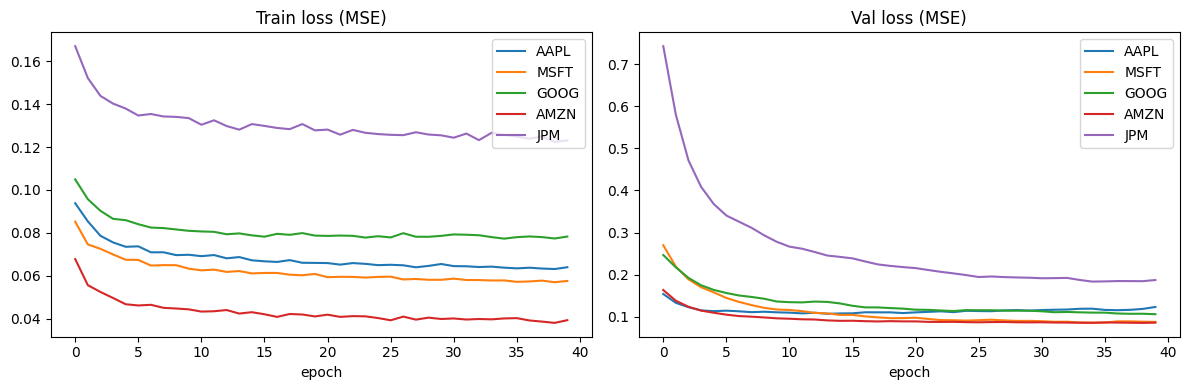

In [7]:
fig, (ax_train, ax_val) = plt.subplots(1, 2, figsize=(12, 4))
for ticker in TICKERS:
    h = history_by_ticker[ticker].history
    ax_train.plot(h["loss"], label=ticker)
    ax_val.plot(h["val_loss"], label=ticker)
ax_train.set_title("Train loss (MSE)")
ax_val.set_title("Val loss (MSE)")
ax_train.legend()
ax_val.legend()
ax_train.set_xlabel("epoch")
ax_val.set_xlabel("epoch")
plt.tight_layout()
plt.show()


## Qualitative check: train history, forecast, rolling-mean baseline

- **Top**: Train-period **Adj Close** plus the LSTM **input window** (last `LOOKBACK` bars) for a chosen validation sample; dashed line at the temporal train/test split.
- **Bottom**: Next `HORIZON` bars — **actual** Adj Close, **LSTM** prediction, and **baseline**: constant forecast = mean Adj Close over the last `BASELINE_WINDOW` bars (default **7**) ending at the last bar of the input window; override with env `SNP_BASELINE_WINDOW`.

Validation MAE over all test windows compares the model to this baseline.


AAPL Val MAE: model=5.3269 USD | rolling-7 baseline=4.9595 USD


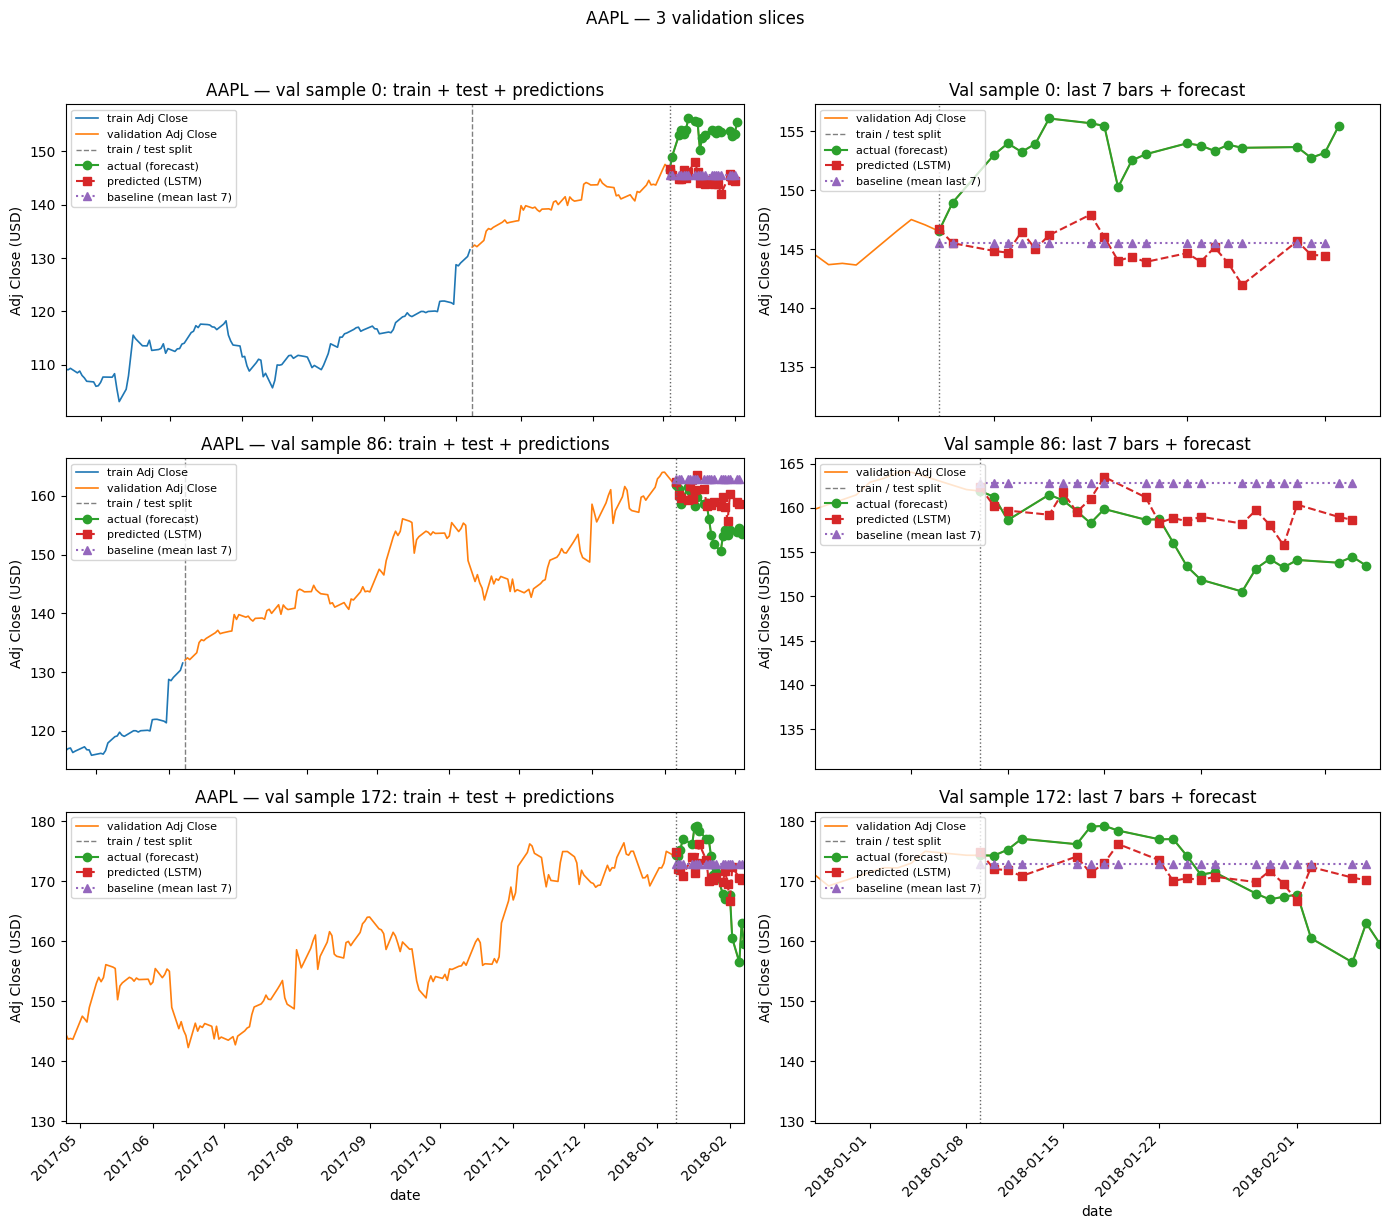

MSFT Val MAE: model=1.9788 USD | rolling-7 baseline=2.1600 USD


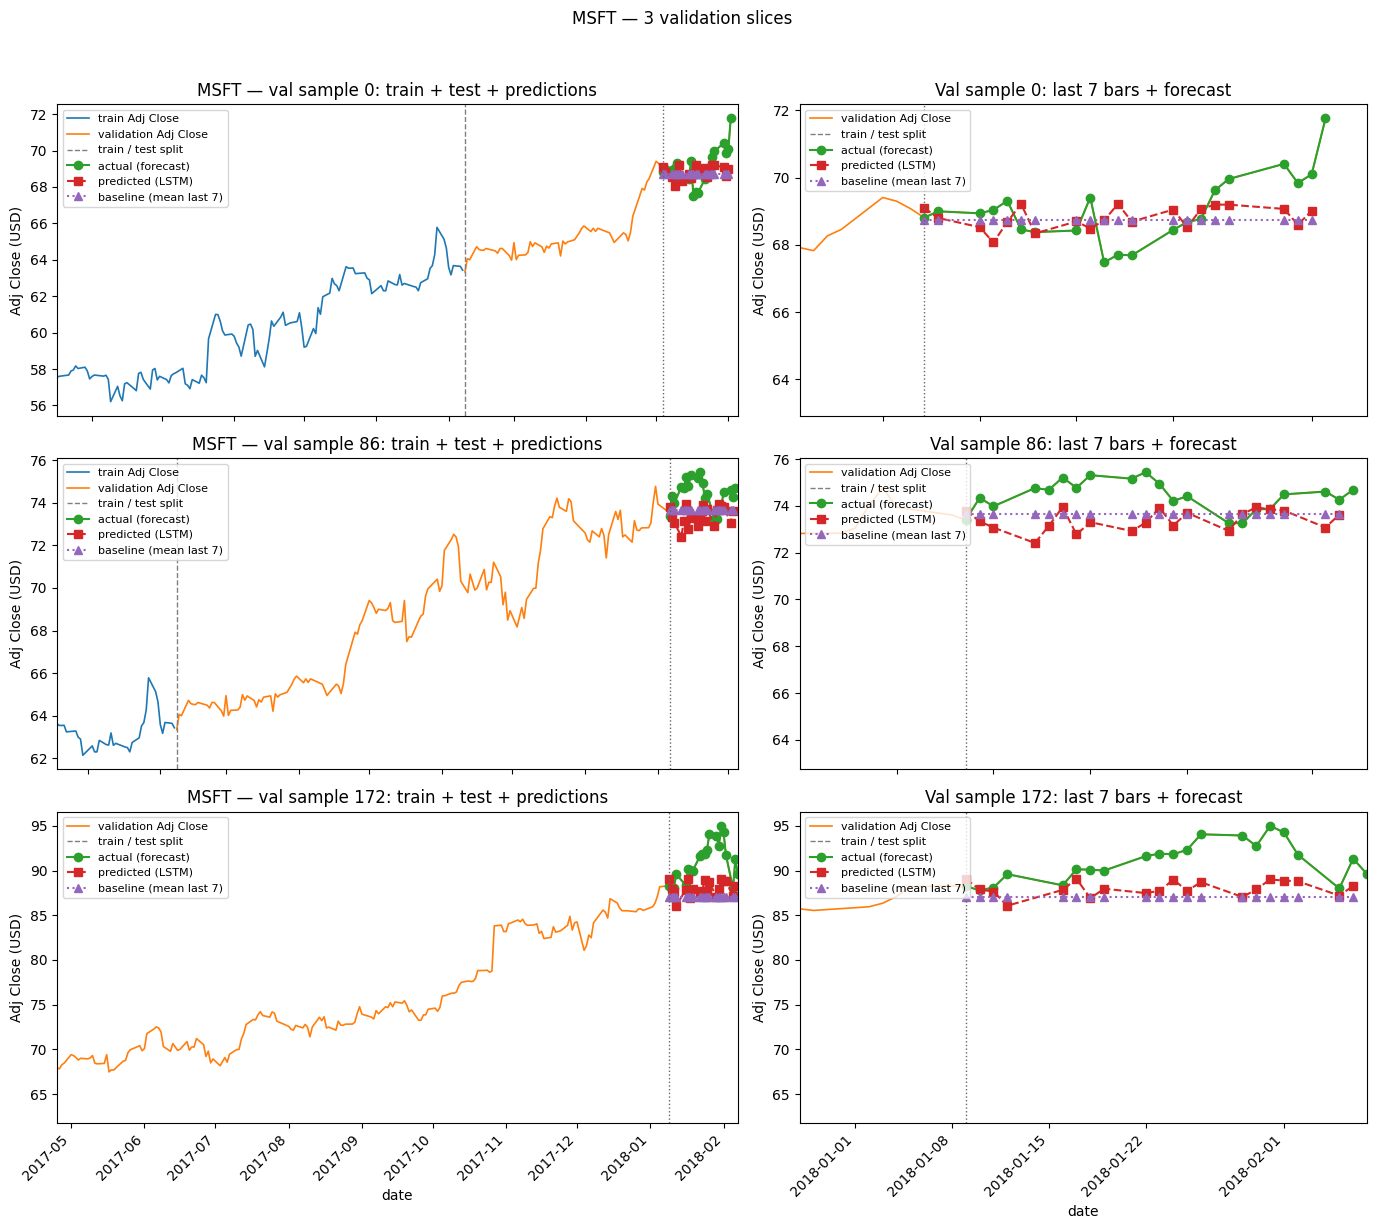

GOOG Val MAE: model=27.0382 USD | rolling-7 baseline=29.6680 USD


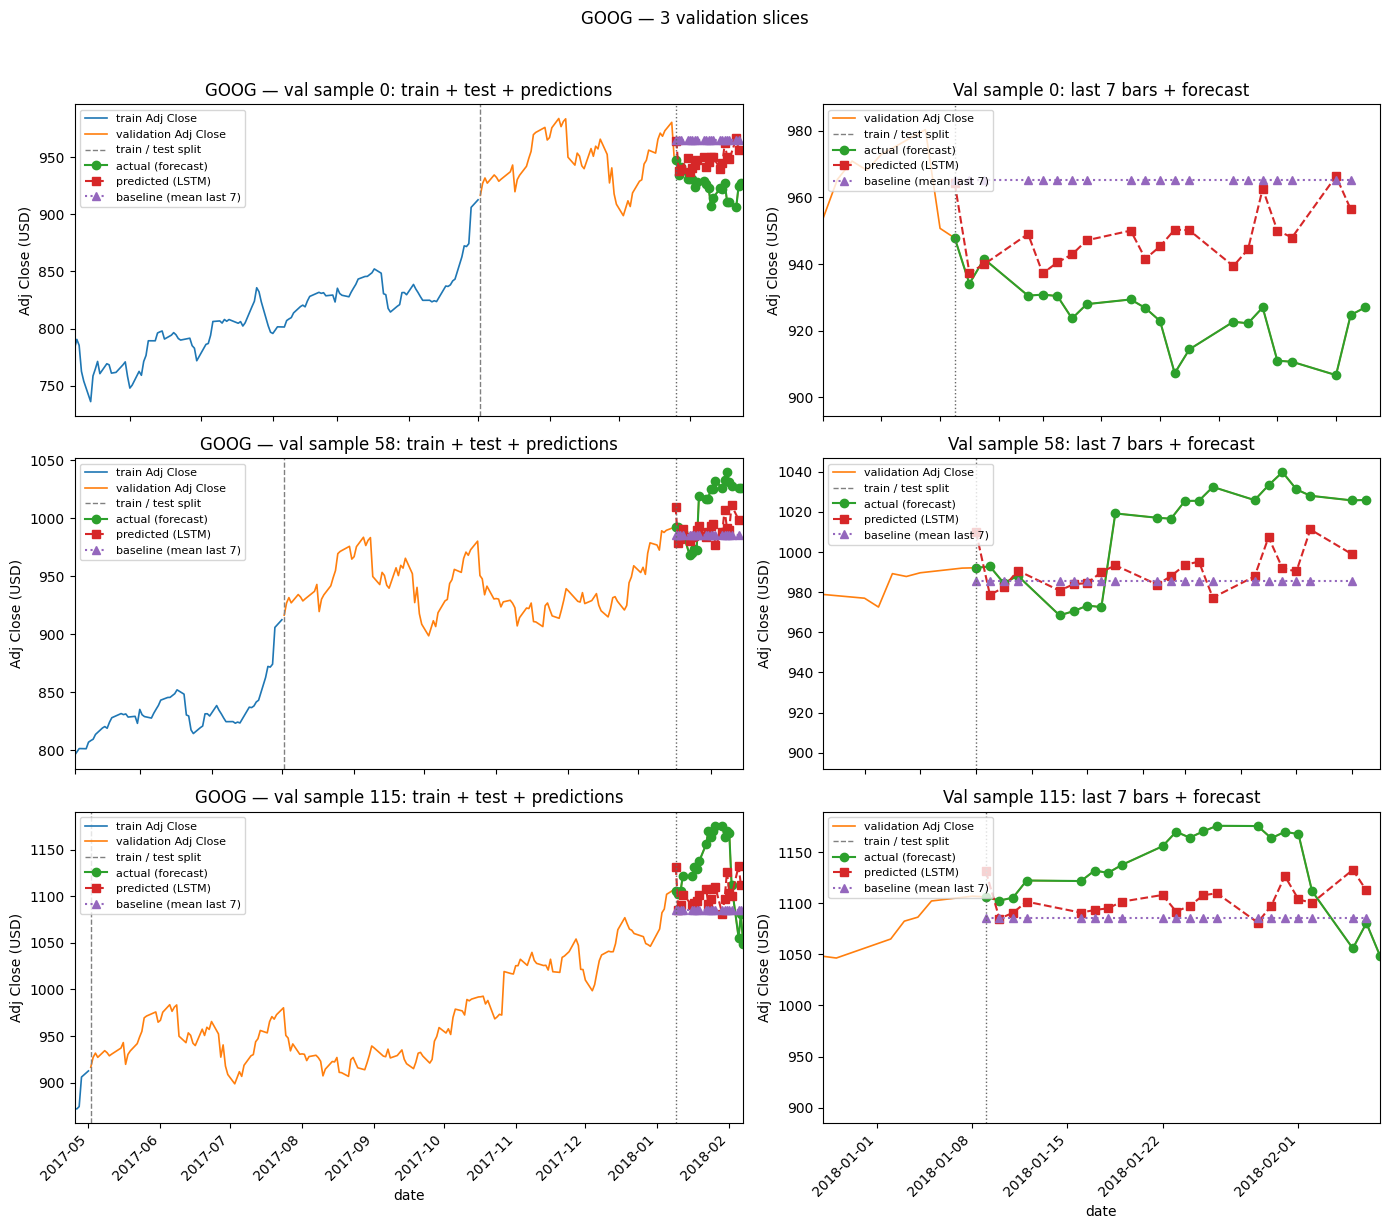

AMZN Val MAE: model=36.3874 USD | rolling-7 baseline=42.3398 USD


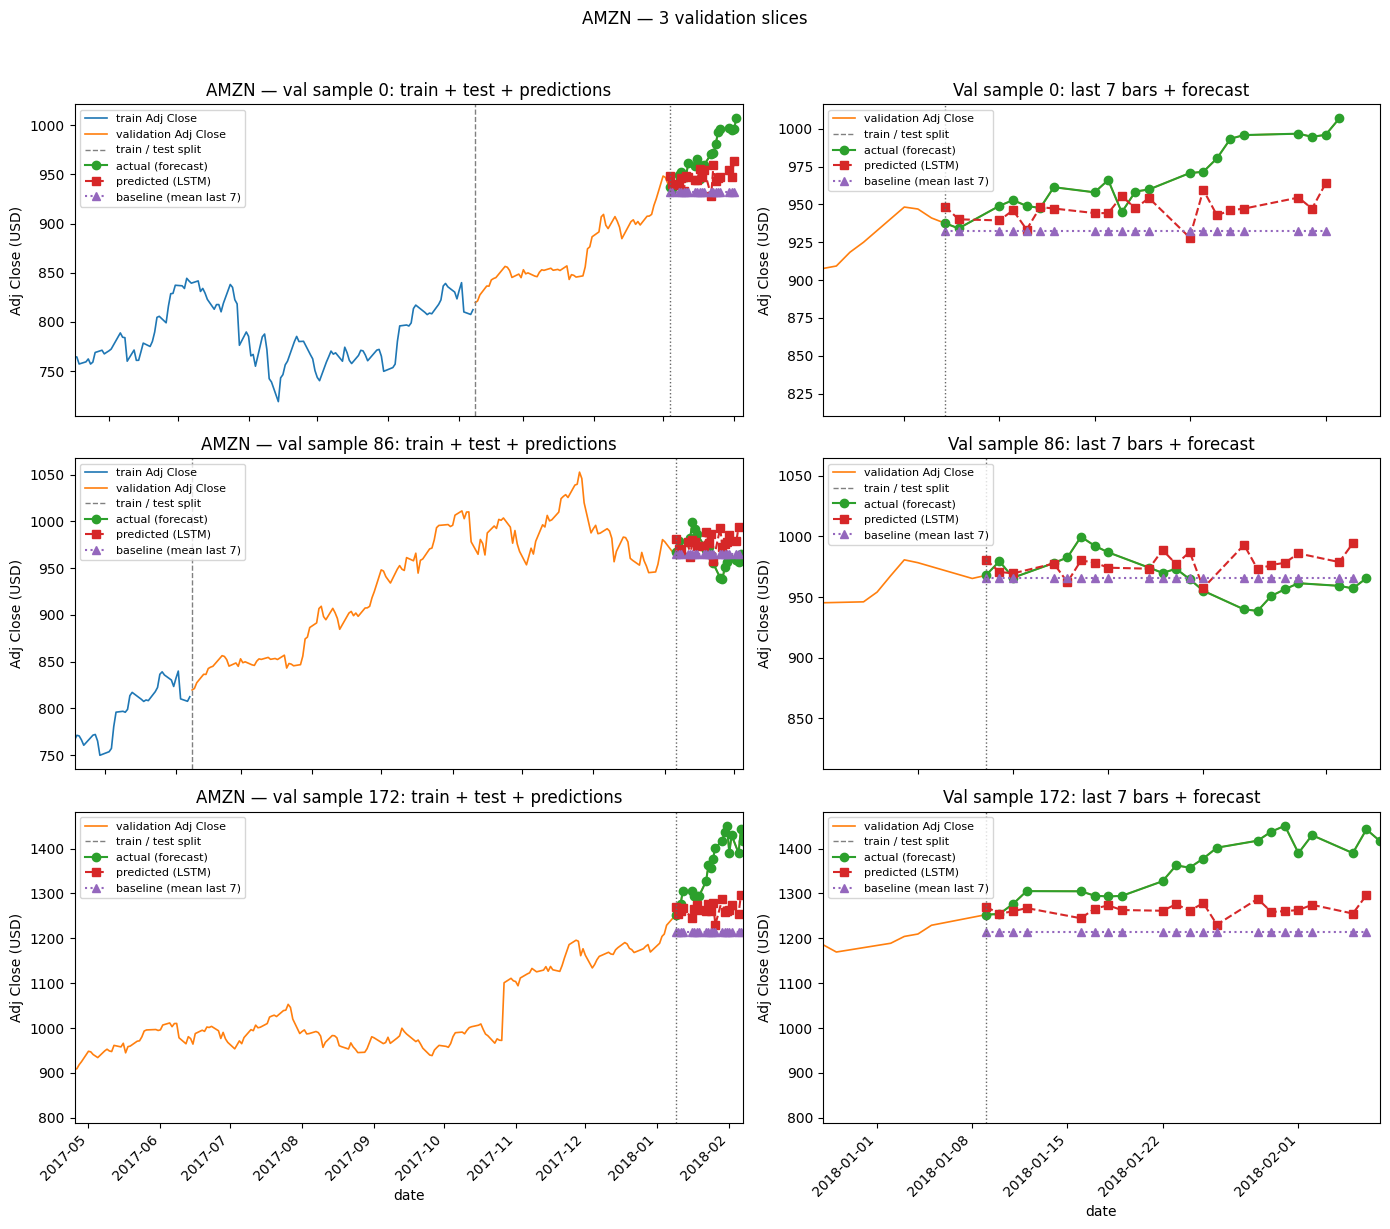

JPM Val MAE: model=2.6693 USD | rolling-7 baseline=3.0154 USD


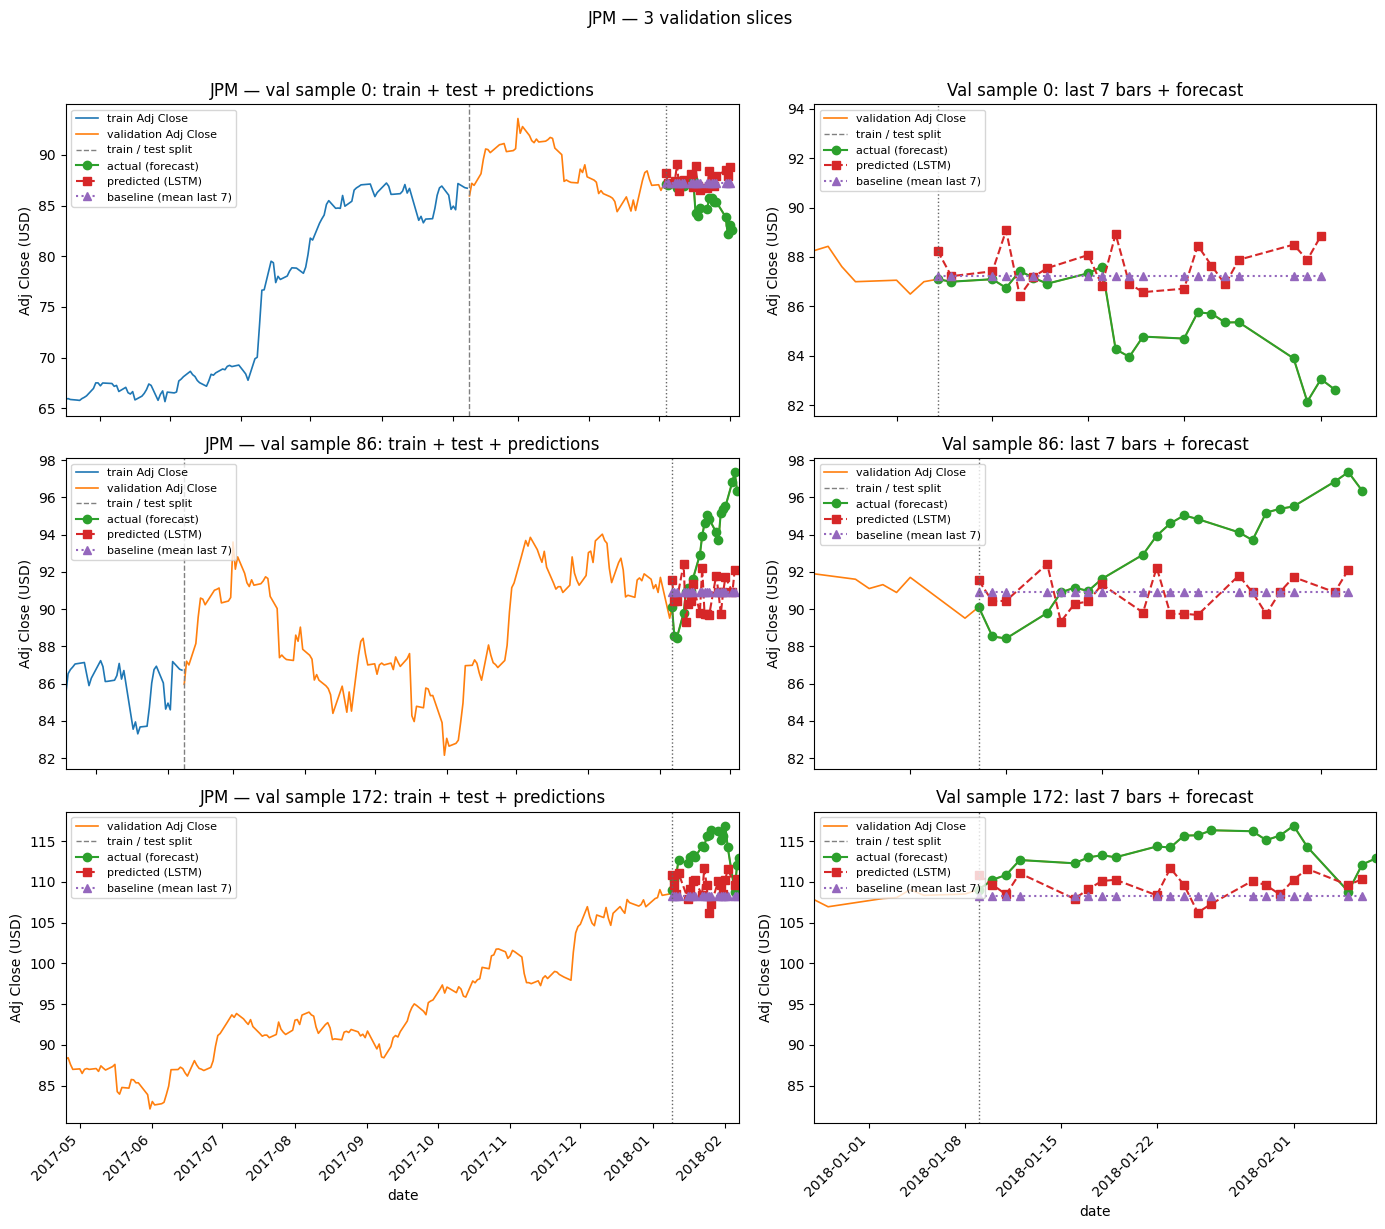

In [8]:
price_i = 0  # univariate Adj Close


def adj_close_baseline_for_val_index(series: pd.DataFrame, split: int, idx: int) -> np.ndarray:
    """Per-sample baseline: repeat rolling mean of Adj Close over last BASELINE_WINDOW bars at forecast start."""
    i = split + idx
    end_lookback = i + LOOKBACK - 1
    lo = max(0, end_lookback - BASELINE_WINDOW + 1)
    b = float(series["Adj Close"].iloc[lo : end_lookback + 1].mean())
    return np.full(HORIZON, b, dtype=np.float64)


for ticker in TICKERS:
    ohlcv = ohlcv_by_ticker[ticker]
    (x_train, y_train, x_val, y_val), scaler = data_by_ticker[ticker]
    mean, std = scaler["mean"], scaler["std"]
    n_bars = len(ohlcv)
    split = int(n_bars * TRAIN_FRAC)

    pred_val = model_by_ticker[ticker].predict(x_val, verbose=0)
    anchor_all = x_val[:, -1, price_i][:, np.newaxis]
    pred_norm_lvl = pred_val + anchor_all
    true_norm_lvl = y_val + anchor_all
    pred_c_all = pred_norm_lvl * std[price_i] + mean[price_i]
    true_c_all = true_norm_lvl * std[price_i] + mean[price_i]
    base_all = np.stack(
        [adj_close_baseline_for_val_index(ohlcv, split, j) for j in range(len(x_val))]
    )
    mae_model = float(np.mean(np.abs(pred_c_all - true_c_all)))
    mae_base = float(np.mean(np.abs(base_all - true_c_all)))
    print(
        f"{ticker} Val MAE: model={mae_model:.4f} USD | "
        f"rolling-{BASELINE_WINDOW} baseline={mae_base:.4f} USD"
    )

    n_val = len(x_val)
    plot_indices = (
        [0, n_val // 2, n_val - 1]
        if n_val >= 3
        else list(range(min(n_val, N_PLOT_SLICES)))
    )

    # Right panel: zoom on the last N bars before the forecast (same N as the rolling-mean baseline).
    N_CONTEXT_BARS = BASELINE_WINDOW
    fig, axes = plt.subplots(
        N_PLOT_SLICES,
        2,
        figsize=(14, 4 * N_PLOT_SLICES),
        gridspec_kw={"width_ratios": [1.2, 1]},
        sharex=False,
        sharey=False,
    )
    price = ohlcv["Adj Close"]
    dates = ohlcv["Date"]

    for row, idx in enumerate(plot_indices[:N_PLOT_SLICES]):
        ax_main, ax_ctx = axes[row, 0], axes[row, 1]
        i = split + idx

        anc = x_val[idx, -1, price_i]
        pred_c = (pred_val[idx] + anc) * std[price_i] + mean[price_i]
        true_c = (y_val[idx] + anc) * std[price_i] + mean[price_i]
        baseline_c = adj_close_baseline_for_val_index(ohlcv, split, idx)

        x0_line = i + LOOKBACK - 1
        lo = max(0, i - 2 * LOOKBACK)
        hi = min(n_bars, x0_line + HORIZON + 1)
        if lo < split:
            t_train = dates.iloc[lo:split]
            price_train = price.iloc[lo:split]
            ax_main.plot(t_train, price_train, color="C0", linewidth=1.2, label="train Adj Close")
        t_val = dates.iloc[split:hi]
        price_val = price.iloc[split:hi]
        ax_main.plot(t_val, price_val, color="C1", linewidth=1.2, label="validation Adj Close")
        ax_main.axvline(
            dates.iloc[split], color="0.5", linestyle="--", linewidth=1, label="train / test split"
        )
        t_fut = dates.iloc[x0_line : x0_line + HORIZON]
        xf = dates.iloc[x0_line : x0_line + HORIZON + 1]
        y_bridge = np.concatenate([[price.iloc[x0_line]], true_c])
        ax_main.plot(xf, y_bridge, "o-", color="C2", label="actual (forecast)", markersize=6)
        ax_main.plot(t_fut, pred_c, "s--", color="C3", label="predicted (LSTM)")
        ax_main.plot(t_fut, baseline_c, "^:", color="C4", label=f"baseline (mean last {BASELINE_WINDOW})")
        ax_main.axvline(dates.iloc[x0_line], color="0.4", linestyle=":", linewidth=1)
        ax_main.set_ylabel("Adj Close (USD)")
        ax_main.set_xlabel("date")
        ax_main.set_title(f"{ticker} — val sample {idx}: train + test + predictions")
        ax_main.legend(loc="upper left", fontsize=8)
        ax_main.set_xlim(dates.iloc[lo], dates.iloc[min(n_bars - 1, x0_line + HORIZON + 1)])

        lo_ctx = max(0, x0_line - N_CONTEXT_BARS)
        hi_ctx = min(n_bars, x0_line + HORIZON + 1)
        if lo_ctx < split:
            t_train_ctx = dates.iloc[lo_ctx:split]
            price_train_ctx = price.iloc[lo_ctx:split]
            ax_ctx.plot(t_train_ctx, price_train_ctx, color="C0", linewidth=1.2, label="train Adj Close")
        t_val_ctx = dates.iloc[split:hi_ctx]
        price_val_ctx = price.iloc[split:hi_ctx]
        ax_ctx.plot(t_val_ctx, price_val_ctx, color="C1", linewidth=1.2, label="validation Adj Close")
        ax_ctx.axvline(
            dates.iloc[split], color="0.5", linestyle="--", linewidth=1, label="train / test split"
        )
        ax_ctx.plot(xf, y_bridge, "o-", color="C2", label="actual (forecast)", markersize=6)
        ax_ctx.plot(t_fut, pred_c, "s--", color="C3", label="predicted (LSTM)")
        ax_ctx.plot(t_fut, baseline_c, "^:", color="C4", label=f"baseline (mean last {BASELINE_WINDOW})")
        ax_ctx.axvline(dates.iloc[x0_line], color="0.4", linestyle=":", linewidth=1)
        ax_ctx.set_ylabel("Adj Close (USD)")
        ax_ctx.set_xlabel("date")
        ax_ctx.set_title(f"Val sample {idx}: last {N_CONTEXT_BARS} bars + forecast")
        ax_ctx.legend(loc="upper left", fontsize=8)
        ax_ctx.set_xlim(dates.iloc[lo_ctx], dates.iloc[min(n_bars - 1, x0_line + HORIZON + 1)])

    fig.autofmt_xdate(rotation=45)
    plt.suptitle(f"{ticker} — {N_PLOT_SLICES} validation slices", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()
